In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv(
    "../data/raw/File.csv",
    encoding="cp1251",
    sep=";",
    on_bad_lines="skip",
    low_memory=False
)

print(data.shape)
data.head()

(368139, 49)


,НомерСтроки,Период,Регистратор,Контрагент,КонтрагентИНН,СчетДт,СубконтоДт1,ВидСубконтоДт1,СубконтоДт2,ВидСубконтоДт2,...,НадписьВР,НадписьКоличествоДт,НадписьКоличествоКт,СчетДтКоличественный,СчетКтКоличественный,СчетДтВалютный,СчетКтВалютный,СчетДтУчетПоПодразделениям,СчетКтУчетПоПодразделениям,Unnamed: 48
0,1,01.01.2024 0:00:00,Операция по единому налоговому счету 00БП-0000...,NaN,NaN,68.12,Налог (взносы): начислено / уплачено,Виды платежей в бюджет (фонды),NaN,NaN,...,ВР:,NaN,NaN,Нет,Нет,Нет,Нет,Нет,Нет,NaN
1,2,01.01.2024 0:00:00,Операция по единому налоговому счету 00БП-0000...,NaN,NaN,69.06.5,Взносы с доходов свыше предела,Виды платежей в бюджет (фонды),NaN,NaN,...,ВР:,NaN,NaN,Нет,Нет,Нет,Нет,Нет,Нет,NaN
2,3,01.01.2024 0:00:00,Операция по единому налоговому счету 00БП-0000...,NaN,NaN,69.06.6,Налог (взносы): начислено / уплачено,Виды платежей в бюджет (фонды),NaN,NaN,...,ВР:,NaN,NaN,Нет,Нет,Нет,Нет,Нет,Нет,NaN
3,1,01.01.2024 12:00:00,Списание с расчетного счета 00БП-000001 от 01....,"ФИЛИАЛ ""ЦЕНТРАЛЬНЫЙ"" БАНКА ВТБ (ПАО)",7702070139,91.02,Расходы на услуги банков,Прочие доходы и расходы,NaN,Реализуемые активы,...,ВР:,NaN,NaN,Нет,Нет,Нет,Нет,Да,Да,NaN
4,1,03.01.2024 9:58:36,"Реализация (акт, накладная, УПД) 00УТ-000011 о...",Розничный покупатель,NaN,90.02.1,Основная номенклатурная группа,Номенклатурные группы,NaN,NaN,...,ВР:,NaN,Кол:,Нет,Да,Нет,Нет,Да,Да,NaN


In [3]:
with open("../data/raw/File.csv", encoding="cp1251") as f:
    total_lines = sum(1 for _ in f) - 1  # минус заголовок

lost = total_lines - len(data)
print(f"Всего строк в файле: {total_lines}")
print(f"Загружено: {len(data)}")
print(f"Потеряно: {lost} ({lost/total_lines*100:.2f}%)")

Всего строк в файле: 368297
Загружено: 368139
Потеряно: 158 (0.04%)


In [4]:
for i in data.columns:
    nan = data[i].isna().mean() * 100
    null = data[i].isnull().mean() * 100
    nunique = data[i].nunique()
    print(f"{i:45s} | nulls: {null:5.1f}% | unique: {nunique} | nan: {nan}")


НомерСтроки                                   | nulls:   0.0% | unique: 237 | nan: 0.0
Период                                        | nulls:   0.0% | unique: 57845 | nan: 0.0
Регистратор                                   | nulls:   0.0% | unique: 66125 | nan: 0.0
Контрагент                                    | nulls:   1.5% | unique: 137 | nan: 1.454341974091308
КонтрагентИНН                                 | nulls:  56.7% | unique: 132 | nan: 56.68375260431522
СчетДт                                        | nulls:   0.0% | unique: 48 | nan: 0.002173092228750554
СубконтоДт1                                   | nulls:   0.8% | unique: 1959 | nan: 0.7711761046778527
ВидСубконтоДт1                                | nulls:   0.7% | unique: 11 | nan: 0.746728817104409
СубконтоДт2                                   | nulls:  39.0% | unique: 6703 | nan: 38.95077674465352
ВидСубконтоДт2                                | nulls:  38.5% | unique: 13 | nan: 38.5471248631631
СубконтоДт3               

In [5]:
print("Сумма:")
print(data["Сумма"].head(10))
print()
print("ВалютнаяСуммаДт:")
print(data["ВалютнаяСуммаДт"].head(10))

Сумма:
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
Name: Сумма, dtype: object

ВалютнаяСуммаДт:
0      476 374
1    82 538,19
2       45 842
3        2 000
4        91,36
5        109,8
6        109,8
7        181,8
8          236
9       421,78
Name: ВалютнаяСуммаДт, dtype: object


In [6]:
print("ВалютнаяСуммаКт:")
print(data["ВалютнаяСуммаКт"].head(10))

ВалютнаяСуммаКт:
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
Name: ВалютнаяСуммаКт, dtype: object


In [7]:
for i in data.columns:
    nan = data[i].isna().mean() * 100
    if nan > 95:
        data.drop([i], axis = 1, inplace=True)

In [8]:
print(data.head())
print(
    data.shape
)

   НомерСтроки               Период  \
0            1   01.01.2024 0:00:00   
1            2   01.01.2024 0:00:00   
2            3   01.01.2024 0:00:00   
3            1  01.01.2024 12:00:00   
4            1   03.01.2024 9:58:36   

                                         Регистратор  \
0  Операция по единому налоговому счету 00БП-0000...   
1  Операция по единому налоговому счету 00БП-0000...   
2  Операция по единому налоговому счету 00БП-0000...   
3  Списание с расчетного счета 00БП-000001 от 01....   
4  Реализация (акт, накладная, УПД) 00УТ-000011 о...   

                             Контрагент КонтрагентИНН   СчетДт  \
0                                   NaN           NaN    68.12   
1                                   NaN           NaN  69.06.5   
2                                   NaN           NaN  69.06.6   
3  ФИЛИАЛ "ЦЕНТРАЛЬНЫЙ" БАНКА ВТБ (ПАО)    7702070139    91.02   
4                  Розничный покупатель           NaN  90.02.1   

                            Суб

# Парсинг дат

0
2024-01-01 00:00:00 2025-12-31 23:59:59
количество значений по часам:
Период
0     16319
6         3
7      1699
8     44107
9     49334
10    40420
11    30700
12    31491
13    28690
14    20647
15    59803
16    23248
17      867
18     1017
19      816
20      306
21      186
22       58
23    18428
Name: count, dtype: int64
количество значений по дням недели:
Период
0    66702
1    66477
2    70274
3    84959
4    76817
5     2102
6      808
Name: count, dtype: int64
количество значений по месяцам:
Период
1     23119
2     27378
3     28982
4     34557
5     32098
6     31170
7     36528
8     34025
9     31691
10    31226
11    26275
12    31090
Name: count, dtype: int64


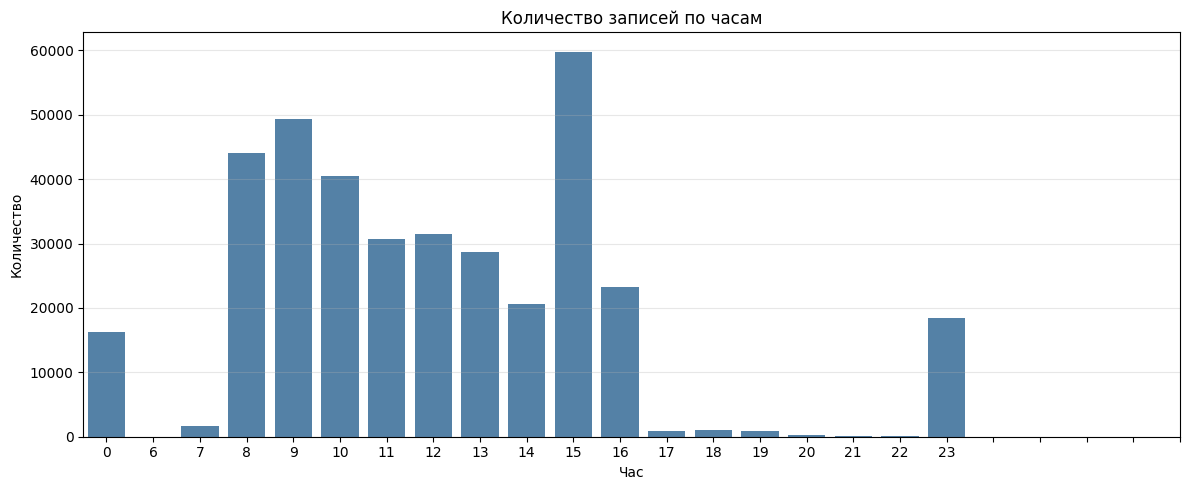

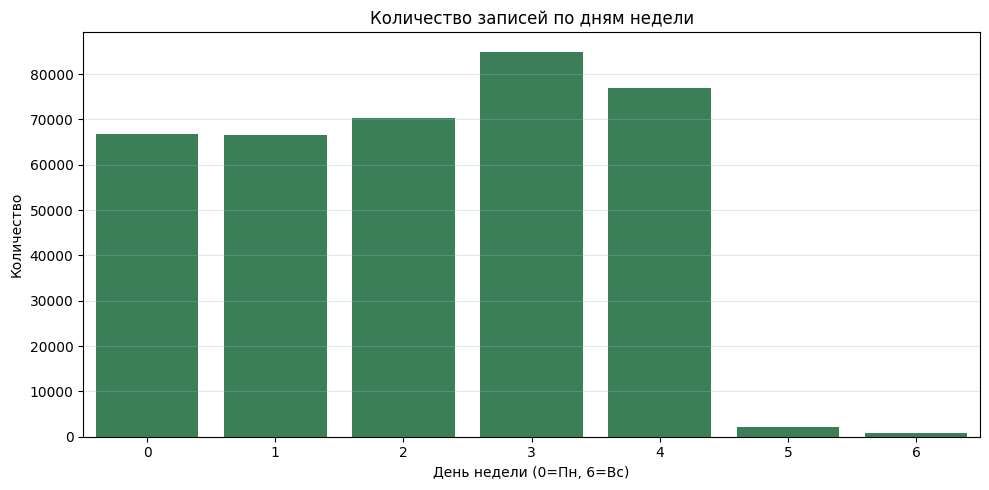

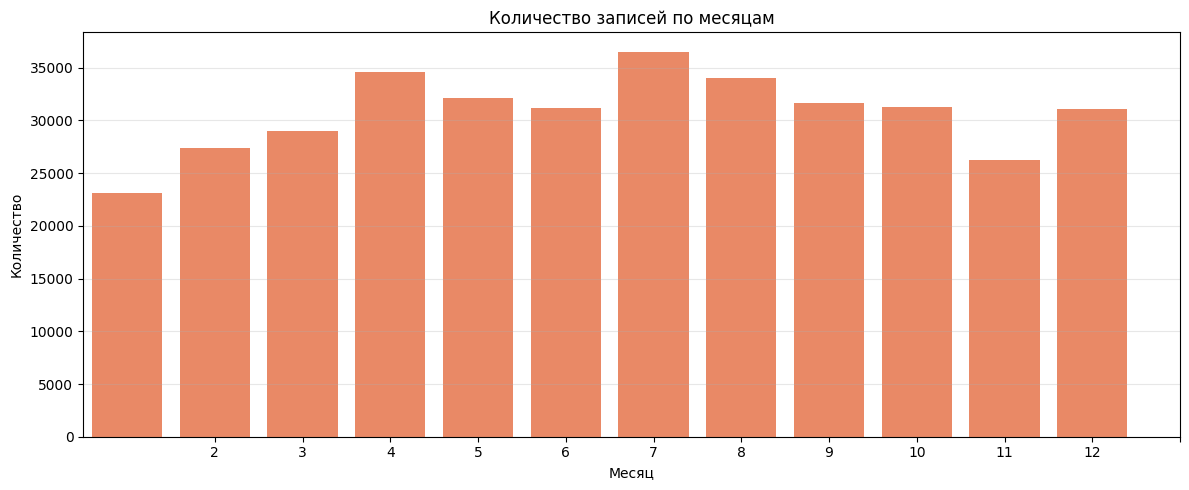

In [9]:
data['Период'] = pd.to_datetime(data['Период'], dayfirst=True, errors='coerce')
print(data['Период'].isnull().sum())
print(data['Период'].min(), data['Период'].max())

hour = data['Период'].dt.hour
hour_counts = hour.value_counts().sort_index()
print(f'количество значений по часам:\n{hour_counts}')

week = data['Период'].dt.dayofweek
week_counts = week.value_counts().sort_index()
print(f'количество значений по дням недели:\n{week_counts}')

month = data['Период'].dt.month
month_counts = month.value_counts().sort_index()
print(f'количество значений по месяцам:\n{month_counts}')

plt.figure(figsize=(12, 5))
sns.barplot(x=hour_counts.index, y=hour_counts.values, color='steelblue')
plt.title('Количество записей по часам')
plt.xlabel('Час')
plt.ylabel('Количество')
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=week_counts.index, y=week_counts.values, color='seagreen')
plt.title('Количество записей по дням недели')
plt.xlabel('День недели (0=Пн, 6=Вс)')
plt.ylabel('Количество')
plt.xticks(range(0, 7))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(x=month_counts.index, y=month_counts.values, color='coral')
plt.title('Количество записей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Парсинг суммы

In [10]:
data["ВалютнаяСуммаДт_original"] = data["ВалютнаяСуммаДт"].copy()

NaN после исправленного парсинга: 106
count    3.680330e+05
mean     4.321354e+03
std      2.633754e+05
min     -1.079092e+05
25%      1.949300e+02
50%      4.800400e+02
75%      1.294920e+03
max      8.812925e+07
Name: Сумма, dtype: float64
Количество записей с суммой <= 0: 4466
Количество записей с суммой == 0: 848


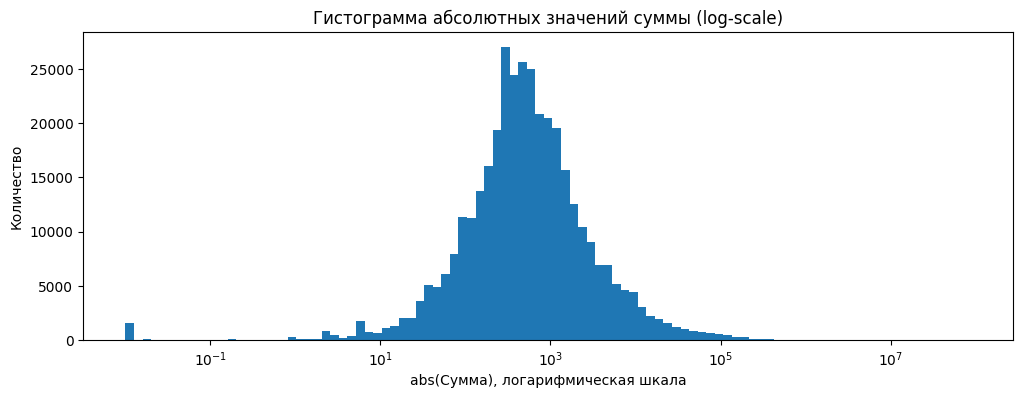

In [11]:
data["Сумма"] = (
    data["ВалютнаяСуммаДт"]
    .astype(str)
    .str.replace(r'[\s\xa0\u202f\u2009]', '', regex=True)  # все виды пробелов
    .str.replace(",", ".", regex=False)
    .str.strip()
)
data["Сумма"] = pd.to_numeric(data["Сумма"], errors="coerce")
print(f"NaN после исправленного парсинга: {data['Сумма'].isnull().sum()}")
print(data["Сумма"].describe())
cnt_0 = (data['Сумма'] <= 0).sum()
cnt_min = (data['Сумма'] == 0).sum()
print(f'Количество записей с суммой <= 0: {cnt_0}')
print(f'Количество записей с суммой == 0: {cnt_min}')

# Гистограмма по абсолютным значениям, чтобы лог-шкала корректно отработала
sum_abs = data['Сумма'].abs()
sum_abs = sum_abs[sum_abs > 0].dropna()
vals = data["Сумма"].dropna().abs()
vals = vals[vals > 0]  # убираем нули для log
plt.figure(figsize=(12, 4))
plt.hist(vals, bins=np.logspace(np.log10(vals.min()), np.log10(vals.max()), 100))
plt.xscale('log')
plt.title("Гистограмма абсолютных значений суммы (log-scale)")
plt.xlabel("abs(Сумма), логарифмическая шкала")
plt.ylabel("Количество")
plt.show()

# Анализ пар счетов

Всего уникальных пар: 119
Пар с 1 операцией: 12
      СчетДт   СчетКт   count
88   90.02.1    41.01  123671
54     62.01  90.01.1  109512
8      41.01    60.01   33415
58     62.02    62.01   26355
90     90.03    68.02   16483
37     57.03    62.02    8936
36     57.03    62.01    8038
39     60.01       51    5959
31        51    62.01    5805
21     50.01    62.02    5654
20     50.01    62.01    5136
4      19.03    60.01    3526
61     68.02    19.03    3507
112       94    41.01    1925
32        51    62.02    1413
41     60.01    60.02    1288
29        51    57.03     874
100    91.02    57.03     869
43     60.01    76.02     839
91   90.07.1    44.01     428


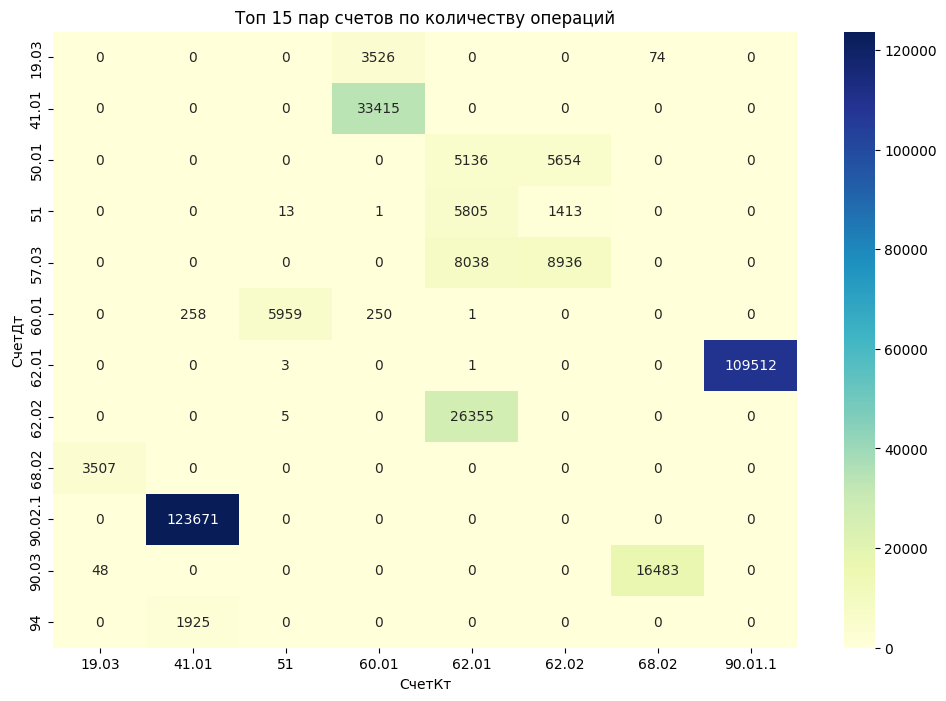

In [12]:
pair_counts = data.groupby(["СчетДт", "СчетКт"]).size().reset_index(name="count")
pair_counts_sorted = pair_counts.sort_values("count", ascending=False)

print(f"Всего уникальных пар: {len(pair_counts)}")
print(f"Пар с 1 операцией: {(pair_counts['count'] == 1).sum()}")
print(pair_counts_sorted.head(20))


top15 = pair_counts_sorted.head(15)
accounts_dt = top15["СчетДт"].unique()
accounts_kt = top15["СчетКт"].unique()

pivot = (
    data[data["СчетДт"].isin(accounts_dt) & data["СчетКт"].isin(accounts_kt)]
    .groupby(["СчетДт", "СчетКт"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Топ 15 пар счетов по количеству операций")
plt.xlabel("СчетКт")
plt.ylabel("СчетДт")
plt.show()


# Анализ контрагентов

уникальных контр агентов: 137
пропусков в Контрагенте: 5354
Количество контрагентов с 1 операцией: 3
Количество контрагентов с 1-5 операциями: 17
Количество контрагентов с 5-10 операциями: 14
Количество контрагентов с 10-50 операциями: 17
Количество контрагентов с 50-100 операциями: 11
Количество остальных : 81


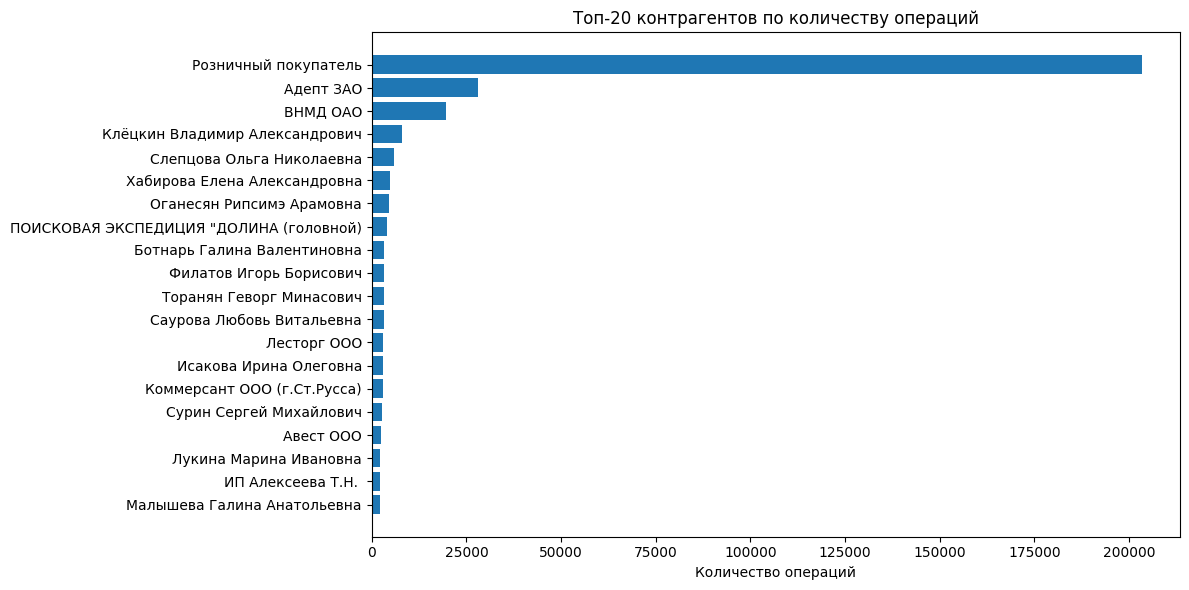

In [13]:
print(f'уникальных контр агентов: {data["Контрагент"].nunique()}')
print(f'пропусков в Контрагенте: {data["Контрагент"].isna().sum()}')

cnts = data["Контрагент"].value_counts()

print(f'Количество контрагентов с 1 операцией: {(cnts == 1).sum()}')
print(f'Количество контрагентов с 1-5 операциями: {(cnts.between(1, 5)).sum()}')
print(f'Количество контрагентов с 5-10 операциями: {(cnts.between(5, 10)).sum()}')
print(f'Количество контрагентов с 10-50 операциями: {(cnts.between(10, 50)).sum()}')
print(f'Количество контрагентов с 50-100 операциями: {(cnts.between(50, 100)).sum()}')
print(f'Количество остальных : {(cnts > 100).sum()}')

top20 = data["Контрагент"].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.barh(top20.index[::-1], top20.values[::-1])
plt.xlabel("Количество операций")
plt.title("Топ-20 контрагентов по количеству операций")
plt.tight_layout()
plt.show()


# Парсинг Регистратора -> ТипДокумента

In [14]:
data["ТипДокумента"] = data["Регистратор"].str.extract(r"^(.+?)\s+\d{2}")
data["ТипДокумента"] = data["ТипДокумента"].str.strip()
print(data["ТипДокумента"].value_counts())

print(f'уникальных типов документов: {data["ТипДокумента"].nunique()}')


ТипДокумента
Реализация (акт, накладная, УПД)             274823
Поступление (акт, накладная, УПД)             36510
Операция по платежной карте                   17021
Поступление наличных                          10849
Поступление на расчетный счет                  9206
Списание с расчетного счета                    6648
Возврат товаров поставщику                     3868
Счет-фактура полученный                        3176
Списание товаров, материалов                   2433
Регламентная операция                          1148
Возврат товаров от покупателя                   852
Формирование записей книги покупок              330
Выдача наличных                                 299
Оприходование товаров                           263
Корректировка долга                             251
Отражение зарплаты в бухучете                   204
Операция                                        117
Уведомление об исчисленных суммах налогов        39
Сведения об удержанном НДФЛ                      24

In [17]:
manual_types = ['Операция']
data['is_manual'] = data['ТипДокумента'].isin(manual_types).astype(int)
print(f"Ручных проводок: {data['is_manual'].sum()} ({data['is_manual'].mean()*100:.2f}%)")

# Кандидаты в whitelist — регламентные операции
whitelist_candidates = ["Регламентная операция", "Уведомление об исчисленных суммах налогов", 
                        "Сведения об удержанном НДФЛ", "Операция по единому налоговому счету"]
print(f"\nКандидаты в whitelist:")
for t in whitelist_candidates:
    cnt = (data["ТипДокумента"] == t).sum()
    print(f"  {t}: {cnt}")


Ручных проводок: 117 (0.03%)

Кандидаты в whitelist:
  Регламентная операция: 1148
  Уведомление об исчисленных суммах налогов: 39
  Сведения об удержанном НДФЛ: 24
  Операция по единому налоговому счету: 3


# Boxplot сумм по типам документов

In [18]:
data.head(5)

,НомерСтроки,Период,Регистратор,Контрагент,КонтрагентИНН,СчетДт,СубконтоДт1,ВидСубконтоДт1,СубконтоДт2,ВидСубконтоДт2,...,СчетДтКоличественный,СчетКтКоличественный,СчетДтВалютный,СчетКтВалютный,СчетДтУчетПоПодразделениям,СчетКтУчетПоПодразделениям,ВалютнаяСуммаДт_original,Сумма,ТипДокумента,is_manual
0,1,2024-01-01 00:00:00,Операция по единому налоговому счету 00БП-0000...,NaN,NaN,68.12,Налог (взносы): начислено / уплачено,Виды платежей в бюджет (фонды),NaN,NaN,...,Нет,Нет,Нет,Нет,Нет,Нет,476 374,476374.00,Операция по единому налоговому счету,0
1,2,2024-01-01 00:00:00,Операция по единому налоговому счету 00БП-0000...,NaN,NaN,69.06.5,Взносы с доходов свыше предела,Виды платежей в бюджет (фонды),NaN,NaN,...,Нет,Нет,Нет,Нет,Нет,Нет,"82 538,19",82538.19,Операция по единому налоговому счету,0
2,3,2024-01-01 00:00:00,Операция по единому налоговому счету 00БП-0000...,NaN,NaN,69.06.6,Налог (взносы): начислено / уплачено,Виды платежей в бюджет (фонды),NaN,NaN,...,Нет,Нет,Нет,Нет,Нет,Нет,45 842,45842.00,Операция по единому налоговому счету,0
3,1,2024-01-01 12:00:00,Списание с расчетного счета 00БП-000001 от 01....,"ФИЛИАЛ ""ЦЕНТРАЛЬНЫЙ"" БАНКА ВТБ (ПАО)",7702070139,91.02,Расходы на услуги банков,Прочие доходы и расходы,NaN,Реализуемые активы,...,Нет,Нет,Нет,Нет,Да,Да,2 000,2000.00,Списание с расчетного счета,0
4,1,2024-01-03 09:58:36,"Реализация (акт, накладная, УПД) 00УТ-000011 о...",Розничный покупатель,NaN,90.02.1,Основная номенклатурная группа,Номенклатурные группы,NaN,NaN,...,Нет,Да,Нет,Нет,Да,Да,"91,36",91.36,"Реализация (акт, накладная, УПД)",0


/var/folders/10/p1df9rqx1078r_zgmfzd7fzh0000gn/T/ipykernel_1710/3705661901.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top['log_amount'] = np.log1p(df_top['Сумма'].abs())


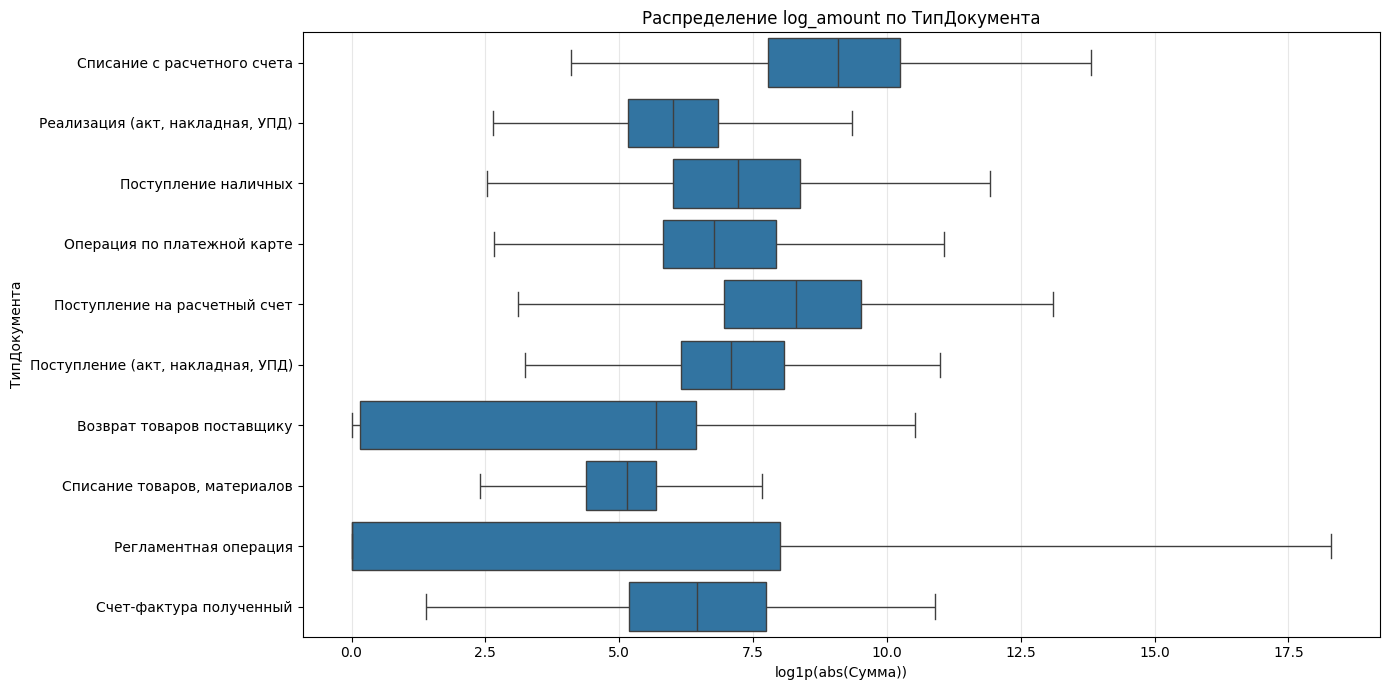

In [27]:
top10 = data["ТипДокумента"].value_counts().head(10).index
df_top = data[data["ТипДокумента"].isin(top10)]
df_top['log_amount'] = np.log1p(df_top['Сумма'].abs())

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_top,
    x="log_amount",
    y="ТипДокумента",
    showfliers=False 
)
plt.title("Распределение log_amount по ТипДокумента")
plt.xlabel("log1p(abs(Сумма))")
plt.ylabel("ТипДокумента")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Субконто

In [28]:
cols = ['СубконтоДт1','СубконтоДт2','СубконтоДт1']
for i in cols:
    print(f'Уникальных значений в {i}: {data[i].nunique()}')
    print(f'Пропусков в {i}: {data[i].isna().sum()}')
    print(data[i].value_counts().head(10))


cols = ['СубконтоКт1','СубконтоКт2','СубконтоКт1']
for i in cols:
    print(f'Уникальных значений в {i}: {data[i].nunique()}')
    print(f'Пропусков в {i}: {data[i].isna().sum()}')
    print(data[i].value_counts().head(10))

Уникальных значений в СубконтоДт1: 1959
Пропусков в СубконтоДт1: 2839
СубконтоДт1
Основная номенклатурная группа                                         140202
Розничный покупатель                                                    92188
ПАО СБЕРБАНК                                                            16974
Поступление оплаты от клиента                                           10790
1688 в НОВГОРОДСКОЕ ОТДЕЛЕНИЕ N 8629 ПАО СБЕРБАНК, Васильев В.Н. ИП      8296
Адепт ЗАО                                                                7188
ВНМД ОАО                                                                 4629
Налог (взносы): начислено / уплачено                                     3677
Клёцкин Владимир Александрович                                           3485
Слепцова Ольга Николаевна                                                2422
Name: count, dtype: int64
Уникальных значений в СубконтоДт2: 6703
Пропусков в СубконтоДт2: 143393
СубконтоДт2
договор с клиентом          

In [30]:
print(data.columns.to_list)

<bound method IndexOpsMixin.tolist of Index(['НомерСтроки', 'Период', 'Регистратор', 'Контрагент', 'КонтрагентИНН',
       'СчетДт', 'СубконтоДт1', 'ВидСубконтоДт1', 'СубконтоДт2',
       'ВидСубконтоДт2', 'СубконтоДт3', 'ВидСубконтоДт3', 'СчетКт',
       'СубконтоКт1', 'ВидСубконтоКт1', 'СубконтоКт2', 'ВидСубконтоКт2',
       'СубконтоКт3', 'ВидСубконтоКт3', 'Организация', 'ПодразделениеДт',
       'ПодразделениеКт', 'ВалютнаяСуммаДт', 'КоличествоДт', 'КоличествоКт',
       'СуммаНУДт', 'СуммаНУКт', 'СуммаПРДт', 'СуммаПРКт', 'СуммаВРДт',
       'СуммаВРКт', 'Содержание', 'НеКорректироватьСтоимостьАвтоматически',
       'НадписьНУ', 'НадписьПР', 'НадписьВР', 'НадписьКоличествоДт',
       'НадписьКоличествоКт', 'СчетДтКоличественный', 'СчетКтКоличественный',
       'СчетДтВалютный', 'СчетКтВалютный', 'СчетДтУчетПоПодразделениям',
       'СчетКтУчетПоПодразделениям', 'ВалютнаяСуммаДт_original', 'Сумма',
       'ТипДокумента', 'is_manual'],
      dtype='object')>
